## GNN Lesson 4: pLM Embeddings as GNN Node Features
### What you'll learn
- The "pLM + GNN" pattern: ESM-2 turns each residue into a high-dimensional
  vector that already encodes evolutionary/biophysical information; the GNN
  then reasons about how those residues interact through a graph.
- Why this combination is so powerful: pLMs encode per-residue context;
  GNNs encode pairwise interactions. They're complementary.

### Compared to gnn_l3
Same task (DeepSol solubility, graph classification), same graph structure
(sequence-window), same model architecture. The ONLY thing that changes:
the node features.

   gnn_l3:  one-hot AA  (20-dim)        -> typically modest accuracy
   gnn_l4:  ESM-2 8M    (320-dim)       -> usually noticeably better

This is one of the most reliably-effective patterns in protein ML.

### Compute note
Extracting ESM-2 embeddings is the expensive step here. We do it ONCE per
sequence and cache them in the Data objects. The GNN training loop afterwards
is fast and CPU-friendly.

> **Run order matters.** The cells below build on each other. Run them **top to bottom** (Jupyter: *Run → Run All Cells*; VS Code: *Run All*). If you hit `NameError: name 'torch' is not defined` (or similar), you skipped the **Setup** cell — run it first.

## Setup — imports & configuration

**Run this cell first.** It imports every library and defines the module-level constants the rest of the notebook relies on.

In [1]:
import torch
import torch.nn.functional as F
from datasets import load_dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
from transformers import AutoModel, AutoTokenizer
PLM_NAME = "facebook/esm2_t6_8M_UR50D"
DATASET_NAME = "proteinea/solubility"
N_TRAIN = 200
N_TEST = 50
WINDOW = 3
MAX_LEN = 400
HIDDEN = 128
HEADS = 4
EPOCHS = 15
BATCH_SIZE = 4
LR = 5e-4
PLM_BATCH_SIZE = 4

In [2]:
# --- MLflow experiment tracking -------------------------------------------
# Import the shared helper regardless of where Jupyter launched from.
# See mlflow_utils.py for the repo-root SQLite backend.
import os, sys
for _cand in (os.path.abspath(""), os.path.dirname(os.path.abspath(""))):
    if os.path.isfile(os.path.join(_cand, "mlflow_utils.py")):
        if _cand not in sys.path:
            sys.path.insert(0, _cand)
        break
import mlflow
import mlflow_utils as mu


### `embed_sequences` (function)

Run ESM-2 over each sequence and return PER-RESIDUE embeddings.

Note: we keep ALL residue embeddings (not pooled), because the GNN
will use them as node features.

Returns: list of tensors, one per sequence, each of shape (L, hidden_dim).

In [3]:
def embed_sequences(sequences, tokenizer, plm, device, batch_size=PLM_BATCH_SIZE):
    all_embs = []
    plm.eval()
    for i in range(0, len(sequences), batch_size):
        batch = [s[:MAX_LEN] for s in sequences[i : i + batch_size]]
        inputs = tokenizer(
            batch, return_tensors="pt",
            padding=True, truncation=True, max_length=MAX_LEN + 2,
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            hidden = plm(**inputs).last_hidden_state    # (B, L+2, D)

        # The tokenizer adds <cls> at index 0 and <eos> at the end. We want
        # one embedding per amino acid, so we slice [1, 1+len(seq)] for each
        # sequence in the batch.
        for j, seq in enumerate(batch):
            emb = hidden[j, 1 : 1 + len(seq)].cpu()
            all_embs.append(emb)

        if (i // batch_size) % 10 == 0:
            print(f"  embedded {min(i + batch_size, len(sequences))}/{len(sequences)}")
    return all_embs

### `make_graph` (function)

Build a PyG Data object using ESM-2 embeddings as node features.

In [4]:
def make_graph(sequence, embedding, label, window=WINDOW):
    n = len(sequence)
    edges = []
    for i in range(n):
        for d in range(1, window + 1):
            if i + d < n:
                edges.append((i, i + d))
                edges.append((i + d, i))
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    return Data(
        x=embedding,                   # (n, plm_hidden_dim)
        edge_index=edge_index,
        y=torch.tensor([label], dtype=torch.long),
    )

### `GATGraphClassifier` (class)

In [5]:
class GATGraphClassifier(torch.nn.Module):
    def __init__(self, in_channels, hidden, out_channels, heads=4):
        super().__init__()
        self.gat1 = GATConv(in_channels, hidden, heads=heads, dropout=0.2)
        self.gat2 = GATConv(hidden * heads, hidden, heads=1, concat=False, dropout=0.2)
        self.classifier = torch.nn.Linear(hidden, out_channels)

    def forward(self, x, edge_index, batch):
        h = F.elu(self.gat1(x, edge_index))
        h = F.elu(self.gat2(h, edge_index))
        return self.classifier(global_mean_pool(h, batch))

### `train_one_epoch` (function)

In [6]:
def train_one_epoch(model, loader, opt, device):
    model.train()
    total = 0.0
    for batch in loader:
        batch = batch.to(device)
        opt.zero_grad()
        logits = model(batch.x, batch.edge_index, batch.batch)
        loss = F.cross_entropy(logits, batch.y)
        loss.backward()
        opt.step()
        total += loss.item() * batch.num_graphs
    return total / len(loader.dataset)

### `evaluate` (function)

In [7]:
def evaluate(model, loader, device):
    model.eval()
    correct = total = 0
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.batch)
        correct += (logits.argmax(dim=-1) == batch.y).sum().item()
        total += batch.num_graphs
    return correct / total

### `main` (function)

In [8]:
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # ---- 1. Load pLM (frozen — we never update its weights) ------------
    print(f"Loading pLM: {PLM_NAME}")
    tokenizer = AutoTokenizer.from_pretrained(PLM_NAME)
    plm = AutoModel.from_pretrained(PLM_NAME).to(device)
    plm_dim = plm.config.hidden_size
    print(f"  pLM hidden dim: {plm_dim}")

    # ---- 2. Load dataset ------------------------------------------------
    print(f"\nLoading dataset: {DATASET_NAME}")
    raw = load_dataset(DATASET_NAME)
    raw = raw.rename_columns({"sequences": "sequence", "labels": "label"})
    raw = raw.map(lambda b: {"label": [int(x) for x in b["label"]]}, batched=True)
    raw = raw.shuffle(seed=42)
    train_raw = raw["train"].select(range(N_TRAIN))
    test_raw = raw["test"].select(range(N_TEST))

    train_seqs = [d["sequence"][:MAX_LEN] for d in train_raw]
    train_labels = [d["label"] for d in train_raw]
    test_seqs = [d["sequence"][:MAX_LEN] for d in test_raw]
    test_labels = [d["label"] for d in test_raw]

    # ---- 3. Extract embeddings (the expensive step) -------------------
    print("\nExtracting train embeddings...")
    train_embs = embed_sequences(train_seqs, tokenizer, plm, device)
    print("Extracting test embeddings...")
    test_embs = embed_sequences(test_seqs, tokenizer, plm, device)

    # Free the pLM — we don't need it for GNN training.
    del plm
    if device == "cuda":
        torch.cuda.empty_cache()

    # ---- 4. Build graphs -----------------------------------------------
    print("\nBuilding graphs (with pLM embeddings as node features)...")
    train_set = [make_graph(s, e, y) for s, e, y in zip(train_seqs, train_embs, train_labels)]
    test_set = [make_graph(s, e, y) for s, e, y in zip(test_seqs, test_embs, test_labels)]

    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE)

    # ---- 5. Train the GNN ----------------------------------------------
    print("\nTraining GAT on top of pLM embeddings...")
    model = GATGraphClassifier(
        in_channels=plm_dim, hidden=HIDDEN, out_channels=2, heads=HEADS
    ).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

    for ep in range(EPOCHS):
        loss = train_one_epoch(model, train_loader, opt, device)
        acc = evaluate(model, test_loader, device)
        print(f"  epoch {ep + 1:3d}  loss={loss:.3f}  test_acc={acc:.3f}")

    final_acc = evaluate(model, test_loader, device)
    print(f"\nFinal test accuracy: {final_acc:.3f}")
    print(
        "\nCompare with gnn_l3 (same architecture, but one-hot AA features). "
        "The accuracy lift here is the value of the pLM."
    )

    print(
        """
Things to experiment with:
- Use a bigger pLM: PLM_NAME = "facebook/esm2_t12_35M_UR50D"
- FINE-TUNE the pLM end-to-end with the GNN: remove `with torch.no_grad()`
  and put the pLM on the optimiser. Massive lift, much more compute.
- Replace the sequence-window graph with a learned k-NN graph on pLM
  embeddings — useful when no real 3D structure is available.
- Use this on a per-residue task instead of graph-level: see gnn_l2.
"""
    )

    # Hand the trained model + data back so the analysis section below can
    with mu.run("gnn-graph-classification", "l4_gat_esm2feats",
                params={"dataset": DATASET_NAME, "plm": PLM_NAME, "model": "GAT",
                        "features": "ESM-2", "n_train": N_TRAIN, "n_test": N_TEST,
                        "hidden": HIDDEN, "heads": HEADS, "epochs": EPOCHS,
                        "batch_size": BATCH_SIZE, "lr": LR},
                tags={"lesson": "gnn_l4", "model": "GAT", "features": "ESM-2"}):
        mlflow.log_metric("test_acc", float(final_acc))

    # reuse the (expensive) ESM-2 embeddings instead of recomputing them.
    return {
        "model": model,
        "device": device,
        "train_set": train_set,
        "test_set": test_set,
        "test_seqs": test_seqs,
        "test_labels": test_labels,
    }

## Run the lesson

Execute everything above, then run `main()`.

In [9]:
ctx = main()

Using device: cuda
Loading pLM: facebook/esm2_t6_8M_UR50D


[transformers] EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  pLM hidden dim: 320

Loading dataset: proteinea/solubility



Extracting train embeddings...


  embedded 4/200
  embedded 44/200
  embedded 84/200


...

  epoch  11  loss=0.308  test_acc=0.460


  epoch  12  loss=0.273  test_acc=0.520


  epoch  13  loss=0.326  test_acc=0.500


  epoch  14  loss=0.247  test_acc=0.440


  epoch  15  loss=0.242  test_acc=0.460

Final test accuracy: 0.460

Compare with gnn_l3 (same architecture, but one-hot AA features). The accuracy lift here is the value of the pLM.

Things to experiment with:
- Use a bigger pLM: PLM_NAME = "facebook/esm2_t12_35M_UR50D"
- FINE-TUNE the pLM end-to-end with the GNN: remove `with torch.no_grad()`
  and put the pLM on the optimiser. Massive lift, much more compute.
- Replace the sequence-window graph with a learned k-NN graph on pLM
  embeddings — useful when no real 3D structure is available.
- Use this on a per-residue task instead of graph-level: see gnn_l2.



## Beyond the accuracy number: where does pLM + GNN actually win?

`main()` returned the trained GAT and the cached ESM-2 embeddings in `ctx`. Now we pin down *what the combination buys*:

1. A **no-graph baseline on the same ESM-2 features**: mean-pool each protein's residue embeddings and fit a logistic regression. This isolates the GNN's contribution — both see identical pLM features, only the GAT uses the graph.
2. The **specific proteins** the GAT gets right that the mean-pool baseline gets wrong.

In [10]:
import numpy as np
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression

model = ctx["model"]
device = ctx["device"]
train_set = ctx["train_set"]
test_set = ctx["test_set"]
test_seqs = ctx["test_seqs"]


# The trained GAT is already in `model` — just read off its predictions.
def gat_predict(ds):
    model.eval()
    preds, confs = [], []
    with torch.no_grad():
        for d in ds:
            b = torch.zeros(d.num_nodes, dtype=torch.long, device=device)
            p = F.softmax(model(d.x.to(device), d.edge_index.to(device), b), dim=-1)[0]
            preds.append(int(p.argmax()))
            confs.append(float(p.max()))
    return np.array(preds), np.array(confs)


gat_pred, gat_conf = gat_predict(test_set)
yte = np.array([int(d.y) for d in test_set])
gat_acc = (gat_pred == yte).mean()

# Baseline: mean-pool the SAME ESM-2 node embeddings -> logistic regression.
# Identical features to the GNN, but NO graph / no message passing.
Xtr = np.stack([d.x.mean(0).numpy() for d in train_set])
ytr = np.array([int(d.y) for d in train_set])
Xte = np.stack([d.x.mean(0).numpy() for d in test_set])
clf = LogisticRegression(max_iter=2000).fit(Xtr, ytr)
base_pred = clf.predict(Xte)
base_acc = (base_pred == yte).mean()
majority = max(ytr.mean(), 1 - ytr.mean())

print(f"Majority-class                     = {majority:.3f}")
print(f"ESM-2 mean-pool + LR  (no graph)   = {base_acc:.3f}")
print(f"ESM-2 + GAT           (uses graph) = {gat_acc:.3f}")

Majority-class                     = 0.545
ESM-2 mean-pool + LR  (no graph)   = 0.440
ESM-2 + GAT           (uses graph) = 0.460


### Specific proteins where the graph wins

Test proteins the ESM-2 **+ GAT** got right while the ESM-2 **mean-pool** baseline got wrong — i.e. cases where letting residues exchange information along the graph (rather than averaging their embeddings) changed the prediction to the correct one. `conf` is the GAT's softmax probability for its predicted class.

In [11]:
LAB = {0: "insoluble", 1: "soluble"}
wins = [i for i in range(len(test_set))
        if gat_pred[i] == yte[i] and base_pred[i] != yte[i]]

print(f"{len(wins)} proteins the ESM-2+GAT got RIGHT but ESM-2 mean-pool+LR got WRONG.\n")
print(f"{'#':>3} {'len':>4} {'true':>10} {'GAT pred':>10} {'conf':>5} {'baseline':>10}")
print("-" * 52)
for i in wins[:10]:
    print(f"{i:>3} {len(test_seqs[i]):>4} {LAB[yte[i]]:>10} {LAB[gat_pred[i]]:>10} "
          f"{gat_conf[i]:>5.2f} {LAB[base_pred[i]]:>10}")

if not wins:
    print("(None this run — with N_TEST=50 the two can tie. Re-run, or raise "
          "N_TRAIN/N_TEST. Both models share the strong ESM-2 features, so the "
          "graph's marginal wins are fewer than in gnn_l3.)")

3 proteins the ESM-2+GAT got RIGHT but ESM-2 mean-pool+LR got WRONG.

  #  len       true   GAT pred  conf   baseline
----------------------------------------------------
  9  182  insoluble  insoluble  0.54    soluble
 11  159  insoluble  insoluble  0.68    soluble
 30  192    soluble    soluble  0.89  insoluble


### The headline

Two contrasts in one chart:
- **majority → mean-pool+LR**: what the ESM-2 embeddings alone buy you (already a lot — this is the pLM doing the heavy lifting).
- **mean-pool+LR → GAT**: what the *graph* adds *on top of* those embeddings.

And remember the cross-notebook comparison: swap these ESM-2 node features back to one-hot (that's exactly `gnn_l3`) and accuracy drops — that gap is the value of the pLM.

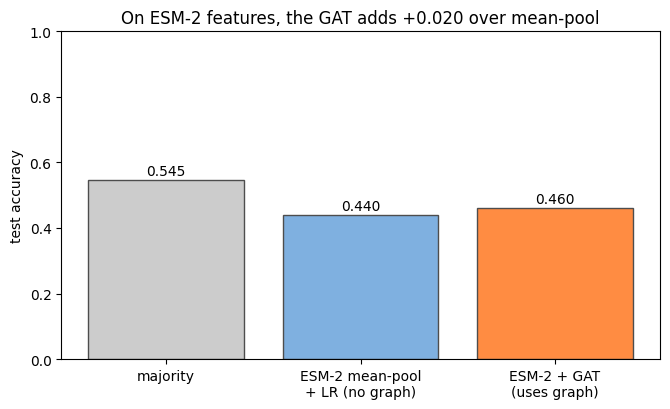

In [12]:
import matplotlib.pyplot as plt

names = ["majority", "ESM-2 mean-pool\n+ LR (no graph)", "ESM-2 + GAT\n(uses graph)"]
vals = [majority, base_acc, gat_acc]
colors = ["#cccccc", "#7fb0e0", "#ff8c42"]

fig, ax = plt.subplots(figsize=(6.8, 4.2))
bars = ax.bar(names, vals, color=colors, edgecolor="0.3")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.006, f"{v:.3f}",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("test accuracy")
ax.set_ylim(0, 1.0)
ax.set_title(f"On ESM-2 features, the GAT adds {gat_acc - base_acc:+.3f} over mean-pool")
plt.tight_layout()
plt.show()